# Layer Pricing with a Scaled Beta Distribution

This notebook does the same style workflow as the lognormal version, but the per-event severity distribution is a scaled Beta on $(0, \theta)$ where $\theta$ is the maximum possible loss (MPL) for the risk.

The five steps stay the same:

1. Two ELTs held as DataFrames: an existing portfolio ELT and a new contract ELT.
2. Fit a scaled Beta to each event's ground-up moments using method of moments.
3. Apply the layer (retention $R$, limit $L$) to get layer mean, layer $\sigma_i$, layer $\sigma_c$ per event.
4. Add the new contract's per-event layered moments to the existing portfolio's per-event layered moments.
5. Read off marginal impact on portfolio AAL and standard deviation.

The last section explores the downsides of using a scaled Beta for layer mean / $\sigma_i$ / $\sigma_c$ modelling, with citations from Klugman, Panjer & Willmot, *Loss Models: From Data to Decisions* (3rd ed., 2008).


In [1]:
import numpy as np
import pandas as pd
from scipy import stats, integrate
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
np.set_printoptions(suppress=True)


## Step 1. ELT data

Each row of the ELT is one simulated event. Columns:

- `event_id`: catalogue ID. The same ID in both ELTs means the same simulated hazard realisation (same storm track, same rupture).
- `rate`: annual occurrence rate.
- `mean_loss`: expected ground-up loss to the risk if the event occurs.
- `sigma_i`: independent standard deviation (idiosyncratic uncertainty: damageability of the specific structure).
- `sigma_c`: correlated standard deviation (shared hazard uncertainty: e.g. wind footprint intensity across the region).
- `mpl`: maximum possible loss for the risk. This is the upper bound of the Beta support and is the parameter that did not appear in the lognormal version.

The two ELTs share the same 10 event IDs so we can demonstrate aggregation by Event ID later.


In [2]:
existing_elt = pd.DataFrame({
    "event_id":  [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "rate":      [0.0050, 0.0080, 0.0120, 0.0200, 0.0300, 0.0150, 0.0100, 0.0040, 0.0020, 0.0010],
    "mean_loss": [12_000_000,  8_500_000,  6_000_000,  4_000_000,  2_500_000,
                   5_000_000,  7_500_000, 15_000_000, 22_000_000, 30_000_000],
    "sigma_i":   [ 4_000_000,  3_000_000,  2_000_000,  1_500_000,  1_000_000,
                   1_800_000,  2_500_000,  5_000_000,  7_000_000,  9_000_000],
    "sigma_c":   [ 3_000_000,  2_500_000,  1_800_000,  1_200_000,    900_000,
                   1_500_000,  2_200_000,  4_500_000,  6_500_000,  8_500_000],
    "mpl":       [100_000_000] * 10,
})

new_elt = pd.DataFrame({
    "event_id":  [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "rate":      [0.0050, 0.0080, 0.0120, 0.0200, 0.0300, 0.0150, 0.0100, 0.0040, 0.0020, 0.0010],
    "mean_loss": [3_000_000, 2_000_000, 1_500_000, 1_000_000,    600_000,
                  1_200_000, 1_800_000, 4_000_000, 6_000_000,  9_000_000],
    "sigma_i":   [1_200_000,   800_000,   600_000,   400_000,    250_000,
                    500_000,   700_000, 1_500_000, 2_200_000,  3_000_000],
    "sigma_c":   [  800_000,   600_000,   450_000,   300_000,    200_000,
                    350_000,   500_000, 1_000_000, 1_500_000,  2_000_000],
    "mpl":       [25_000_000] * 10,
})

existing_elt


,event_id,rate,mean_loss,sigma_i,sigma_c,mpl
0,1001,0.0050,12000000,4000000,3000000,100000000
1,1002,0.0080,8500000,3000000,2500000,100000000
2,1003,0.0120,6000000,2000000,1800000,100000000
3,1004,0.0200,4000000,1500000,1200000,100000000
4,1005,0.0300,2500000,1000000,900000,100000000
5,1006,0.0150,5000000,1800000,1500000,100000000
6,1007,0.0100,7500000,2500000,2200000,100000000
7,1008,0.0040,15000000,5000000,4500000,100000000
8,1009,0.0020,22000000,7000000,6500000,100000000
9,1010,0.0010,30000000,9000000,8500000,100000000


In [3]:
new_elt


,event_id,rate,mean_loss,sigma_i,sigma_c,mpl
0,1001,0.0050,3000000,1200000,800000,25000000
1,1002,0.0080,2000000,800000,600000,25000000
2,1003,0.0120,1500000,600000,450000,25000000
3,1004,0.0200,1000000,400000,300000,25000000
4,1005,0.0300,600000,250000,200000,25000000
5,1006,0.0150,1200000,500000,350000,25000000
6,1007,0.0100,1800000,700000,500000,25000000
7,1008,0.0040,4000000,1500000,1000000,25000000
8,1009,0.0020,6000000,2200000,1500000,25000000
9,1010,0.0010,9000000,3000000,2000000,25000000


## Step 2. Fit a scaled Beta to each event

Let $X$ be the ground-up loss for a single event. We assume $X \sim \theta \cdot \mathrm{Beta}(\alpha, \beta)$ with support $(0, \theta)$ where $\theta$ is the MPL.

For a $\mathrm{Beta}(\alpha, \beta)$ random variable $Y$ on $(0, 1)$:

$$\mathbb{E}[Y] = \frac{\alpha}{\alpha + \beta}, \qquad \mathrm{Var}[Y] = \frac{\alpha\beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$$

After scaling by $\theta$:

$$\mu = \mathbb{E}[X] = \theta \cdot \frac{\alpha}{\alpha + \beta}, \qquad \sigma^2 = \mathrm{Var}[X] = \theta^2 \cdot \frac{\alpha\beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$$

The total variance feeding the fit is the sum of the independent and correlated components:

$$\sigma_{\text{total}}^2 = \sigma_i^2 + \sigma_c^2$$

Define normalised moments $m = \mu / \theta$ and $v = \sigma_{\text{total}}^2 / \theta^2$. Solving for the Beta parameters gives:

$$\phi = \frac{m(1 - m)}{v} - 1, \qquad \alpha = m \phi, \qquad \beta = (1 - m) \phi$$

The quantity $\phi$ is the Beta concentration. A larger $\phi$ means the distribution is more concentrated near the mean. The fit only has a valid solution when $v < m(1 - m)$, otherwise $\phi \le 0$ and no Beta on $(0, \theta)$ matches both the mean and the variance. In that case the practitioner has to either raise $\theta$ or fall back to a different family.


In [4]:
def fit_beta(df: pd.DataFrame) -> pd.DataFrame:
    """Fit a scaled Beta to each row's (mean_loss, sigma_total, mpl) via method of moments.

    Adds columns: sigma_total, m, v, phi, alpha, beta_param.
    Raises ValueError if any row violates the moment-matching constraint v < m*(1-m).
    """
    out = df.copy()
    out["sigma_total"] = np.sqrt(out["sigma_i"] ** 2 + out["sigma_c"] ** 2)
    out["m"] = out["mean_loss"] / out["mpl"]
    out["v"] = (out["sigma_total"] / out["mpl"]) ** 2

    feasible = out["v"] < out["m"] * (1 - out["m"])
    if not feasible.all():
        bad = out.loc[~feasible, ["event_id", "m", "v"]]
        raise ValueError(f"Beta MoM infeasible for these events:\n{bad}")

    out["phi"] = out["m"] * (1 - out["m"]) / out["v"] - 1
    out["alpha"] = out["m"] * out["phi"]
    out["beta_param"] = (1 - out["m"]) * out["phi"]
    return out


existing_fit = fit_beta(existing_elt)
new_fit = fit_beta(new_elt)
existing_fit[["event_id", "mean_loss", "sigma_total", "mpl", "alpha", "beta_param"]]


,event_id,mean_loss,sigma_total,mpl,alpha,beta_param
0,1001,12000000,"5,000,000.0000",100000000,4.9488,36.2912
1,1002,8500000,"3,905,124.8380",100000000,4.2500,45.7500
2,1003,6000000,"2,690,724.8094",100000000,4.6140,72.2865
3,1004,4000000,"1,920,937.2712",100000000,4.1226,98.9424
4,1005,2500000,"1,345,362.4047",100000000,3.3417,130.3268
5,1006,5000000,"2,343,074.9028",100000000,4.2760,81.2449
6,1007,7500000,"3,330,165.1611",100000000,4.6167,56.9396
7,1008,15000000,"6,726,812.0235",100000000,4.0765,23.1003
8,1009,22000000,"9,552,486.5873",100000000,3.9172,13.8883
9,1010,30000000,"12,379,418.4031",100000000,3.8109,8.8922


The `alpha` and `beta_param` columns are the two Beta shape parameters per event. Notice that they vary considerably across events, since events with very small mean relative to MPL tend to push $\alpha$ towards small values, which in turn produces J-shaped densities concentrated near zero.


In [5]:
new_fit[["event_id", "mean_loss", "sigma_total", "mpl", "alpha", "beta_param"]]


,event_id,mean_loss,sigma_total,mpl,alpha,beta_param
0,1001,3000000,"1,442,220.5102",25000000,3.6877,27.0431
1,1002,2000000,"1,000,000.0000",25000000,3.6000,41.4000
2,1003,1500000,"750,000.0000",25000000,3.7000,57.9667
3,1004,1000000,"500,000.0000",25000000,3.8000,91.2000
4,1005,600000,"320,156.2119",25000000,3.4039,138.4254
5,1006,1200000,"610,327.7808",25000000,3.6322,72.0389
6,1007,1800000,"860,232.5267",25000000,3.9911,51.4413
7,1008,4000000,"1,802,775.6377",25000000,3.9754,20.8708
8,1009,6000000,"2,662,705.3911",25000000,3.6190,11.4600
9,1010,9000000,"3,605,551.2755",25000000,3.6277,6.4492


## Step 3. Apply the layer

The layer is defined by retention $R$ and limit $L$. The layered loss is:

$$Y = \min\bigl(\max(X - R,\ 0),\ L\bigr)$$

### Layer mean

The expected layered loss is the integral of the survival function of $X$ across the layer:

$$\mathbb{E}[Y] = \int_R^{R + L} \bigl(1 - F_X(x)\bigr) \, dx$$

Plain English: walk from the retention $R$ up to the cap $R + L$ and add up the probability that the loss exceeds each level. Each unit of probability that the loss exceeds level $x$ is one unit of expected layered loss.

For our scaled Beta, $F_X(x) = I_{x/\theta}(\alpha, \beta)$ where $I$ is the regularised incomplete Beta function. We compute the integral numerically with `scipy.integrate.quad`.

### Layer second moment and variance

$$\mathbb{E}[Y^2] = \int_0^{L} 2y \, \mathbb{P}(Y > y) \, dy = \int_0^{L} 2y \cdot \bigl(1 - F_X(R + y)\bigr) \, dy$$

This is the standard "tail integral" formula for the second moment of a non-negative random variable. The factor $2y$ comes from differentiating $y^2$.

Then:

$$\mathrm{Var}[Y] = \mathbb{E}[Y^2] - \mathbb{E}[Y]^2$$

### Splitting layer variance into $\sigma_i^{(\text{layer})}$ and $\sigma_c^{(\text{layer})}$

The layer transformation is non-linear, so the ground-up split between $\sigma_i$ and $\sigma_c$ does not pass through it analytically. Tiger Eye holds the split fixed in proportion to the ground-up variance contributions:

$$f_i = \frac{\sigma_i^2}{\sigma_i^2 + \sigma_c^2}, \qquad f_c = \frac{\sigma_c^2}{\sigma_i^2 + \sigma_c^2}$$

$$\sigma_i^{(\text{layer})} = \sqrt{f_i \cdot \mathrm{Var}[Y]}, \qquad \sigma_c^{(\text{layer})} = \sqrt{f_c \cdot \mathrm{Var}[Y]}$$

Plain English: keep the same proportional balance of independent vs. correlated uncertainty after the layer as before. This is an approximation. Section "Downsides" discusses why it can be off when the layer is far into the tail.


In [6]:
def layered_moments_beta(mu: float, sigma_i: float, sigma_c: float, mpl: float,
                          alpha: float, beta_param: float,
                          retention: float, limit: float):
    """Compute (layer_mean, layer_var) for one event under a scaled Beta(alpha, beta) on (0, mpl)."""

    def S(x: float) -> float:
        if x <= 0.0:
            return 1.0
        if x >= mpl:
            return 0.0
        return 1.0 - stats.beta.cdf(x / mpl, alpha, beta_param)

    R = retention
    L = limit
    upper = min(R + L, mpl)

    if R >= mpl:
        return 0.0, 0.0

    layer_mean, _ = integrate.quad(S, R, upper, limit=200, epsabs=1.0, epsrel=1e-6)

    def integrand_e2(y):
        return 2.0 * y * S(R + y)

    layer_e2, _ = integrate.quad(integrand_e2, 0.0, upper - R, limit=200, epsabs=1.0, epsrel=1e-6)

    layer_var = max(layer_e2 - layer_mean ** 2, 0.0)
    return layer_mean, layer_var


def apply_layer_beta(fit_df: pd.DataFrame, retention: float, limit: float) -> pd.DataFrame:
    """Apply a (retention, limit) layer to every row of a Beta-fit ELT."""
    out = fit_df.copy()
    means, sdis, sdcs = [], [], []
    for _, row in out.iterrows():
        m_layer, v_layer = layered_moments_beta(
            row["mean_loss"], row["sigma_i"], row["sigma_c"], row["mpl"],
            row["alpha"], row["beta_param"],
            retention, limit,
        )
        sig_total_sq = row["sigma_i"] ** 2 + row["sigma_c"] ** 2
        if sig_total_sq > 0:
            f_i = (row["sigma_i"] ** 2) / sig_total_sq
            f_c = (row["sigma_c"] ** 2) / sig_total_sq
        else:
            f_i = f_c = 0.0
        means.append(m_layer)
        sdis.append(np.sqrt(f_i * v_layer))
        sdcs.append(np.sqrt(f_c * v_layer))
    out["layer_mean"] = means
    out["layer_sigma_i"] = sdis
    out["layer_sigma_c"] = sdcs
    return out


RETENTION = 5_000_000
LIMIT = 20_000_000

existing_layer = apply_layer_beta(existing_fit, RETENTION, LIMIT)
new_layer = apply_layer_beta(new_fit, RETENTION, LIMIT)

existing_layer[["event_id", "mean_loss", "layer_mean", "layer_sigma_i", "layer_sigma_c"]]


,event_id,mean_loss,layer_mean,layer_sigma_i,layer_sigma_c
0,1001,12000000,"7,016,092.6608","3,831,114.5869","2,873,335.9402"
1,1002,8500000,"3,742,025.9383","2,763,182.8770","2,302,652.3975"
2,1003,6000000,"1,580,186.8072","1,581,884.9078","1,423,696.4170"
3,1004,4000000,"408,546.9703","774,560.8338","619,648.6671"
4,1005,2500000,"50,242.3490","223,053.7861","200,748.4075"
5,1006,5000000,"922,039.9636","1,221,270.0984","1,017,725.0820"
6,1007,7500000,"2,815,272.4762","2,225,601.2441","1,958,529.0948"
7,1008,15000000,"9,684,691.0218","4,358,147.4135","3,922,332.6722"
8,1009,22000000,"14,380,955.9942","4,292,701.2031","3,986,079.6886"
9,1010,30000000,"17,276,711.3533","3,370,349.9101","3,183,108.2484"


In [7]:
new_layer[["event_id", "mean_loss", "layer_mean", "layer_sigma_i", "layer_sigma_c"]]


,event_id,mean_loss,layer_mean,layer_sigma_i,layer_sigma_c
0,1001,3000000,"93,404.4894","329,968.0076","219,978.6717"
1,1002,2000000,"5,340.2065","61,482.2078","46,111.6558"
2,1003,1500000,227.1426,"10,619.1319","7,964.3489"
3,1004,1000000,0.3062,306.0551,229.5413
4,1005,600000,0.0000,1.0861,0.8688
5,1006,1200000,11.7414,"2,194.7281","1,536.3096"
6,1007,1800000,"1,236.0582","27,126.9291","19,376.3779"
7,1008,4000000,"365,356.4549","720,462.2959","480,308.1972"
8,1009,6000000,"1,600,960.6432","1,692,341.6157","1,153,869.2834"
9,1010,9000000,"4,178,987.8961","2,781,866.5442","1,854,577.6961"


The chart below shows ground-up mean loss vs. layer mean loss for the existing portfolio. Events whose ground-up mean is well below the retention give near-zero layer mean. Events whose ground-up mean is large enough to push deep into the layer give layer means that approach the limit.


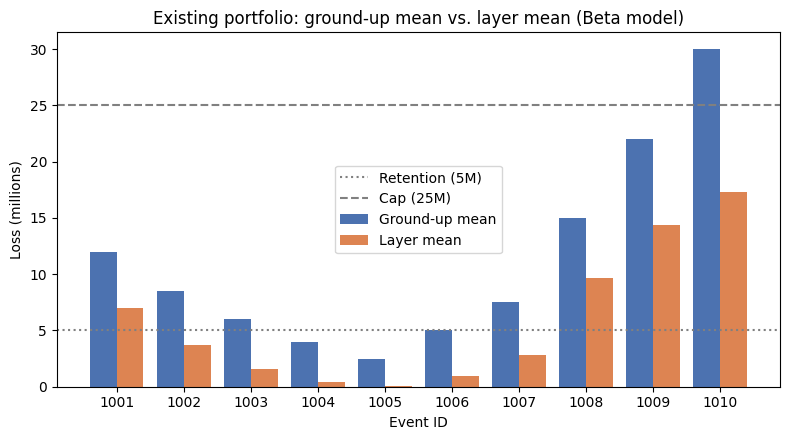

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(existing_layer))
width = 0.4
ax.bar(x - width / 2, existing_layer["mean_loss"] / 1e6, width, label="Ground-up mean", color="#4c72b0")
ax.bar(x + width / 2, existing_layer["layer_mean"] / 1e6, width, label="Layer mean", color="#dd8452")
ax.axhline(RETENTION / 1e6, color="grey", linestyle=":", label=f"Retention ({RETENTION/1e6:.0f}M)")
ax.axhline((RETENTION + LIMIT) / 1e6, color="grey", linestyle="--", label=f"Cap ({(RETENTION+LIMIT)/1e6:.0f}M)")
ax.set_xticks(x)
ax.set_xticklabels(existing_layer["event_id"], rotation=0)
ax.set_xlabel("Event ID")
ax.set_ylabel("Loss (millions)")
ax.set_title("Existing portfolio: ground-up mean vs. layer mean (Beta model)")
ax.legend()
plt.tight_layout()
plt.show()


## Step 4. Add the new contract to the existing portfolio

For every Event ID, the existing portfolio's ELT row and the new contract's ELT row both refer to the same hazard realisation. Aggregating them follows three rules:

### Mean adds linearly

$$\mu_{\text{port + new}}(k) = \mu_{\text{port}}(k) + \mu_{\text{new}}(k)$$

Expected losses are linear regardless of correlation.

### Independent $\sigma$ adds in quadrature

$$\sigma_i^{(\text{port + new})}(k) = \sqrt{\bigl(\sigma_i^{(\text{port})}(k)\bigr)^2 + \bigl(\sigma_i^{(\text{new})}(k)\bigr)^2}$$

Independent uncertainties are uncorrelated by definition. Variances sum, then take the square root.

### Correlated $\sigma$ adds linearly

$$\sigma_c^{(\text{port + new})}(k) = \sigma_c^{(\text{port})}(k) + \sigma_c^{(\text{new})}(k)$$

Both portions are driven by the same hazard footprint for event $k$, so they move together perfectly. Linear addition (correlation $= 1$) is the right rule.

This linear-in-$\sigma_c$ rule is exactly why correlated exposure has a disproportionate marginal impact on portfolio risk.


In [9]:
def add_to_portfolio(port_layer: pd.DataFrame, new_layer: pd.DataFrame) -> pd.DataFrame:
    merged = port_layer.merge(
        new_layer[["event_id", "rate", "layer_mean", "layer_sigma_i", "layer_sigma_c"]],
        on=["event_id", "rate"],
        suffixes=("_port", "_new"),
    )
    merged["layer_mean_total"] = merged["layer_mean_port"] + merged["layer_mean_new"]
    merged["layer_sigma_i_total"] = np.sqrt(
        merged["layer_sigma_i_port"] ** 2 + merged["layer_sigma_i_new"] ** 2
    )
    merged["layer_sigma_c_total"] = (
        merged["layer_sigma_c_port"] + merged["layer_sigma_c_new"]
    )
    return merged


combined = add_to_portfolio(existing_layer, new_layer)
cols = ["event_id", "rate",
        "layer_mean_port", "layer_mean_new", "layer_mean_total",
        "layer_sigma_i_port", "layer_sigma_i_new", "layer_sigma_i_total",
        "layer_sigma_c_port", "layer_sigma_c_new", "layer_sigma_c_total"]
combined[cols]


,event_id,rate,layer_mean_port,layer_mean_new,layer_mean_total,layer_sigma_i_port,layer_sigma_i_new,layer_sigma_i_total,layer_sigma_c_port,layer_sigma_c_new,layer_sigma_c_total
0,1001,0.0050,"7,016,092.6608","93,404.4894","7,109,497.1501","3,831,114.5869","329,968.0076","3,845,298.1502","2,873,335.9402","219,978.6717","3,093,314.6119"
1,1002,0.0080,"3,742,025.9383","5,340.2065","3,747,366.1448","2,763,182.8770","61,482.2078","2,763,866.7974","2,302,652.3975","46,111.6558","2,348,764.0533"
2,1003,0.0120,"1,580,186.8072",227.1426,"1,580,413.9498","1,581,884.9078","10,619.1319","1,581,920.5503","1,423,696.4170","7,964.3489","1,431,660.7659"
3,1004,0.0200,"408,546.9703",0.3062,"408,547.2764","774,560.8338",306.0551,"774,560.8943","619,648.6671",229.5413,"619,878.2084"
4,1005,0.0300,"50,242.3490",0.0000,"50,242.3490","223,053.7861",1.0861,"223,053.7861","200,748.4075",0.8688,"200,749.2763"
5,1006,0.0150,"922,039.9636",11.7414,"922,051.7050","1,221,270.0984","2,194.7281","1,221,272.0704","1,017,725.0820","1,536.3096","1,019,261.3916"
6,1007,0.0100,"2,815,272.4762","1,236.0582","2,816,508.5344","2,225,601.2441","27,126.9291","2,225,766.5574","1,958,529.0948","19,376.3779","1,977,905.4727"
7,1008,0.0040,"9,684,691.0218","365,356.4549","10,050,047.4767","4,358,147.4135","720,462.2959","4,417,297.2277","3,922,332.6722","480,308.1972","4,402,640.8694"
8,1009,0.0020,"14,380,955.9942","1,600,960.6432","15,981,916.6373","4,292,701.2031","1,692,341.6157","4,614,250.0760","3,986,079.6886","1,153,869.2834","5,139,948.9720"
9,1010,0.0010,"17,276,711.3533","4,178,987.8961","21,455,699.2494","3,370,349.9101","2,781,866.5442","4,370,130.4312","3,183,108.2484","1,854,577.6961","5,037,685.9445"


## Step 5. Portfolio metrics and marginal impact

For a compound-Poisson view across events, with each event having annual rate $\lambda_k$ and a single-occurrence layered loss with mean $\mu_k$ and variance $\sigma_{\text{total},k}^2 = (\sigma_{i,k})^2 + (\sigma_{c,k})^2$:

$$\text{AAL} = \sum_k \lambda_k \mu_k$$

$$\mathrm{Var}_{\text{annual}} = \sum_k \lambda_k \cdot \mathbb{E}[X_k^2] = \sum_k \lambda_k \bigl(\mu_k^2 + \sigma_{\text{total},k}^2\bigr)$$

$$\sigma_{\text{annual}} = \sqrt{\mathrm{Var}_{\text{annual}}}$$

Plain English: AAL is the rate-weighted sum of layer means. Annual variance under a Poisson frequency model equals the rate-weighted sum of per-event second moments $\mu_k^2 + \sigma_k^2$.

The marginal impact of adding the new contract is the difference between portfolio metrics computed on `layer_mean_total` and on `layer_mean_port`.


In [10]:
def portfolio_metrics(layer_df: pd.DataFrame, mean_col: str, sigma_i_col: str, sigma_c_col: str):
    rate = layer_df["rate"]
    mu = layer_df[mean_col]
    s_i = layer_df[sigma_i_col]
    s_c = layer_df[sigma_c_col]
    aal = float((rate * mu).sum())
    annual_var = float((rate * (mu ** 2 + s_i ** 2 + s_c ** 2)).sum())
    return aal, np.sqrt(annual_var)


port_aal, port_sd = portfolio_metrics(
    combined, "layer_mean_port", "layer_sigma_i_port", "layer_sigma_c_port"
)
total_aal, total_sd = portfolio_metrics(
    combined, "layer_mean_total", "layer_sigma_i_total", "layer_sigma_c_total"
)
new_aal, new_sd = portfolio_metrics(
    new_layer, "layer_mean", "layer_sigma_i", "layer_sigma_c"
)

summary = pd.DataFrame({
    "metric": ["AAL", "Annual std dev"],
    "existing portfolio": [port_aal, port_sd],
    "new contract standalone": [new_aal, new_sd],
    "portfolio + new": [total_aal, total_sd],
    "marginal impact": [total_aal - port_aal, total_sd - port_sd],
})
summary


,metric,existing portfolio,new contract standalone,portfolio + new,marginal impact
0,AAL,"220,417.8340","9,367.3476","229,785.1817","9,367.3476"
1,Annual std dev,"1,489,682.2927","215,830.9290","1,609,927.2077","120,244.9149"


Two things to read off this table:

1. The marginal AAL is exactly the new contract standalone AAL. AAL is linear, so this is mechanical.
2. The marginal standard deviation is **less than** the new contract standalone standard deviation. The independent uncertainty diversifies. The size of the gap depends on how much of the new contract's variance is independent vs. correlated and how much correlated mass overlaps with the existing portfolio's correlated mass on the same events.


In [11]:
marginal_sd_diversification = (port_sd + new_sd) - total_sd
print(f"Naive sum of standalone SDs: {(port_sd + new_sd):,.0f}")
print(f"Actual portfolio + new SD:    {total_sd:,.0f}")
print(f"Diversification benefit:      {marginal_sd_diversification:,.0f}")


Naive sum of standalone SDs: 1,705,513
Actual portfolio + new SD:    1,609,927
Diversification benefit:      95,586


## Downsides of using a scaled Beta for layer mean / $\sigma_i$ / $\sigma_c$

This section is grounded in *Loss Models: From Data to Decisions* (Klugman, Panjer & Willmot, 3rd ed., 2008), referred to below as KPW. Page numbers are from that edition.

### 1. The textbook does not classify Beta as a tool for large-loss / cat work

KPW organises continuous distributions in Appendix A. The Beta and generalised Beta sit in **Section A.6 "Distributions with finite support" (pp. 680 to 681)**, while the distributions used for excess and reinsurance work sit in **Section A.4 "Distributions for large losses"**. The placement is itself a position. Layer means and the $\sigma_i$ / $\sigma_c$ split for cat ELTs live in the right tail, and the textbook does not group Beta with the family it uses there.

### 2. The MPL has to be set in advance and is not estimable inside the family

The Beta as written in KPW (A.6.1.2) takes parameters $\alpha$, $\beta$, $\theta$ and assumes $\theta$ is known. The single-parameter Pareto note on the same page makes the convention explicit: *"Although there appear to be two parameters, only $\alpha$ is a true parameter. The value of $\theta$ must be set in advance."* Beta inherits the same convention.

For us, $\theta$ is the MPL. Layer mean, layer $\sigma_i$ and layer $\sigma_c$ are all sensitive to the choice of MPL, and the choice is made outside the fit. The MoM estimators KPW give for Beta (A.6.1.2, p. 681) are explicit functions of $\theta$:

$$\hat\alpha = \frac{\theta m^2 - m t}{\theta t - \theta m^2}, \qquad \hat\beta = \frac{(\theta m - t)(\theta - m)}{\theta t - \theta m^2}$$

where $m$ is the sample mean and $t$ is the sample second raw moment. Move $\theta$ and the entire fitted shape moves with it.

### 3. Beta has finite right endpoint, which the authors call out as poor for insurance

KPW Section 5.6.1 (p. 85) introduces the extreme-value Weibull and remarks: *"[The EVT-Weibull] is often associated with the distribution of the minimum values of distributions and with distributions that have a finite right-hand endpoint of the support of the distribution. Because insurance losses rarely have these characteristics, this model is not discussed further in this book."* Beta has a finite right endpoint by construction, so the same critique applies.

### 4. Beta is light-tailed by the textbook's own classification

KPW Section 3.4.1 (p. 35) on tail classification by moments: *"It is generally agreed that the existence of all positive moments indicates a (relatively) light right tail, while the existence of only positive moments up to a certain value (or existence of no positive moments at all) indicates a heavy right tail."* Beta has bounded support, so every positive moment is finite, which puts it on the light-tail side of this dichotomy.

The "characteristics" diagram on p. 76 (Figure 5.4) makes the same point visually: Beta sits with the always-finite-moments family. The distributions used for cat severity (lognormal, Pareto, Burr, generalised Pareto) sit on the heavy-tail side.

For Tiger Eye, the practical consequence is that high-attaching layers (the ones most exposed to tail events) get layer means and layer variances that are systematically optimistic compared to a heavier-tailed fit on the same $(\mu, \sigma_{\text{total}})$ pair.

### 5. EVT, not Beta, is the textbook's recommended family for excess and reinsurance work

KPW Section 5.6.1 (p. 84): *"There are times when actuaries are only interested in the distribution of large losses. One example would be per-claim reinsurance arrangements... It turns out that there is theory to support the choice of particular models for this situation."* The chapter goes on to introduce the Gumbel, Fréchet, Weibull (EVT) and generalised Pareto. Beta is not in the list.

For a layer mean and $\sigma_i$ / $\sigma_c$ used to price an excess-of-loss treaty, the asymptotic theory points to a generalised Pareto for excesses over a high threshold, not a Beta on $(0, \theta)$.

### 6. Method of moments is fragile, and KPW recommends against it when the tail matters

KPW Section 15.2.1 (p. 381): *"Estimation by the method of moments and percentile matching is often easy to do, but these estimators tend to perform poorly mainly because they use a few features of the data, rather than the entire set of observations. It is particularly important to use as much information as possible when the population has a heavy right tail."* Section 15.2 also notes (p. 376) *"there is no guarantee that the equations will have a solution or, if there is a solution, that it will be unique."*

For our Beta MoM, the constraint $\sigma_{\text{total}}^2 < \mu(\theta - \mu)$ is exactly the "no solution" pathology. An ELT row whose total $\sigma$ is large relative to its mean can fail the constraint, and the analyst then has to either inflate $\theta$ (which silently rebalances the tail) or fall back to a different family.

### 7. The proportional split of layer variance into $\sigma_i$ and $\sigma_c$ is approximate

The Beta layer transformation gives a single layer variance via the limited expected value approach. Splitting that variance into $\sigma_i^{(\text{layer})}$ and $\sigma_c^{(\text{layer})}$ in proportion to the ground-up split is an assumption, not a result. KPW does not address this directly because it does not work with the $\sigma_i$ / $\sigma_c$ decomposition that RMS uses in ELTs. The split is reasonable for moderate layers where the ground-up shape is not strongly distorted, and increasingly off as the layer attaches further into the tail.

### 8. Practical workaround if Beta is required for downstream reasons

If a Beta is needed (for example because a downstream pricing model assumes bounded support), two stabilisers help in practice. First, set $\theta$ to a defensible MPL based on engineering exposure, not to a moment-feasibility patch. Second, sanity-check the layer mean against an EVT-based fit (generalised Pareto on excesses) for the high-attaching layers. A material gap between the two layer means is a signal that the Beta tail is the wrong shape for that risk.


## Summary

The notebook walks through five steps. Two ELTs as DataFrames; method-of-moments fit of a scaled Beta to each event; analytic limited-expected-value style layer transformation to get layer mean and layer variance; proportional split into layer $\sigma_i$ and layer $\sigma_c$; Event-ID-wise aggregation under the three rules (mean linear, $\sigma_i$ in quadrature, $\sigma_c$ linear); compound Poisson roll-up to AAL and annual standard deviation. The result is the marginal AAL and marginal standard deviation contributed by the new contract.

The downsides section grounds the model choice in KPW. The honest summary is that a scaled Beta is a tractable but light-tailed, finite-support family that the canonical actuarial reference does not group with the tools used for excess and reinsurance work. It will do a serviceable job for layers that sit close to the body of the loss distribution, and it will tend to under-state risk for high layers.
